# AIME quartile delta analysis

This notebook compares each dataset index's eval solve rate against its initial pass@1 baseline from the AIME quartiles dataset.

Expected CSV columns:
- `dataset_index`
- `id`
- `name`
- `solve_rate`

If your CSV does not have a `step` column, the notebook extracts it from `name` when it contains `step_XXXX`.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display

def estimate_pass_at_k(num_samples: int, num_correct: int, k: int) -> float:
    """Estimate pass@k for one prompt."""
    if num_samples < 1:
        raise ValueError(f"num_samples must be >= 1, got {num_samples}.")
    if not (0 <= num_correct <= num_samples):
        raise ValueError(
            f"num_correct must satisfy 0 <= num_correct <= num_samples, got {num_correct} with {num_samples}."
        )
    if not (1 <= k <= num_samples):
        raise ValueError(f"k must satisfy 1 <= k <= num_samples, got {k} with {num_samples}.")
    if num_samples - num_correct < k:
        return 1.0
    return 1.0 - (math.comb(num_samples - num_correct, k) / math.comb(num_samples, k))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATASET_REPO = "mnoukhov/aime2024-25-rlvr-olmo3-7b-base-pass64-quartiles"
DATASET_SPLIT = "test"
EVAL_CSV_PATH = Path("../notebooks/wandb_export.csv")


In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower()).strip("_") for col in df.columns]
    return df


def parse_step_from_name(name: str) -> int:
    match = re.search(r"step_(\d+)", str(name))
    if match is None:
        raise ValueError(f"Could not parse a step from {name!r}")
    return int(match.group(1))


def load_baseline(dataset_repo: str, split: str) -> pd.DataFrame:
    ds = load_dataset(dataset_repo, split=split)
    df = normalize_columns(ds.to_pandas())

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            df["dataset_index"] = np.arange(len(df), dtype=int)

    if "pass_count" not in df.columns:
        if "pass_rate" not in df.columns:
            raise ValueError("The baseline dataset needs pass_count or pass_rate.")
        df["pass_count"] = df["pass_rate"].map(lambda value: int(str(value).split("/", 1)[0]))

    required_columns = {"dataset_index", "dataset", "num_samples", "pass_count"}
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["num_samples"] = pd.to_numeric(df["num_samples"], errors="raise").astype(int)
    df["pass_count"] = pd.to_numeric(df["pass_count"], errors="raise").astype(int)
    df["initial_pass_at_1"] = [
        estimate_pass_at_k(num_samples=int(num_samples), num_correct=int(pass_count), k=1)
        for pass_count, num_samples in zip(df["pass_count"], df["num_samples"])
    ]
    df["quartile"] = df["dataset"].astype(str).str.extract(r"quartile(\d+)").astype("Int64")

    return df[["dataset_index", "dataset", "quartile", "pass_count", "num_samples", "initial_pass_at_1"]]


def load_eval_csv(path: Path) -> pd.DataFrame:
    df = normalize_columns(pd.read_csv(path))

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            raise ValueError("The eval CSV needs a dataset_index column.")

    if "solve_rate" not in df.columns:
        if "pass_rate" in df.columns:
            df = df.rename(columns={"pass_rate": "solve_rate"})
        else:
            raise ValueError("The eval CSV needs a solve_rate column.")

    if "step" not in df.columns:
        if "name" not in df.columns:
            raise ValueError("The eval CSV needs either a step column or a name column containing step_XXXX.")
        df["step"] = df["name"].map(parse_step_from_name)

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["solve_rate"] = pd.to_numeric(df["solve_rate"], errors="raise")
    df["step"] = pd.to_numeric(df["step"], errors="raise").astype(int)

    return df


In [3]:
baseline = load_baseline(DATASET_REPO, DATASET_SPLIT)
eval_df = load_eval_csv(EVAL_CSV_PATH)

merged = eval_df.merge(
    baseline,
    on="dataset_index",
    how="left",
    validate="many_to_one",
)
merged["delta_vs_initial_pass_at_1"] = merged["solve_rate"] - merged["initial_pass_at_1"]
merged = merged.sort_values(["quartile", "dataset_index", "step"]).reset_index(drop=True)

display(merged.head())
display(merged[["step", "delta_vs_initial_pass_at_1"]].groupby("step", as_index=False).mean())


,dataset_index,id,name,solve_rate,step,dataset,quartile,pass_count,num_samples,initial_pass_at_1,delta_vs_initial_pass_at_1
0,0,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.781250,200,math_aime_quartile0,0,22,64,0.34375,0.437500
1,0,eh5wi7gu,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.859375,400,math_aime_quartile0,0,22,64,0.34375,0.515625
2,0,yoqi90ri,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,600,math_aime_quartile0,0,22,64,0.34375,0.562500
3,0,p9bx5c8r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.953125,800,math_aime_quartile0,0,22,64,0.34375,0.609375
4,0,j29e73ju,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,1000,math_aime_quartile0,0,22,64,0.34375,0.562500


,step,delta_vs_initial_pass_at_1
0,200,0.125000
1,400,0.137760
2,600,0.159896
3,800,0.166406
4,1000,0.185677
5,1200,0.191667
6,1400,0.189844
7,1600,0.199740
8,1800,0.210677
9,2000,0.209896


In [4]:
eval_df

,dataset_index,id,name,solve_rate,step
0,0,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.968750,2400
1,1,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.984375,2400
2,2,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,1.000000,2400
3,3,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.984375,2400
4,4,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.406250,2400
...,...,...,...,...,...
835,55,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.000000,200
836,56,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.031250,200
837,57,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.000000,200
838,58,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.015625,200


In [5]:
DIFFICULTY_ORDER = ["easy", "medium", "hard"]
DIFFICULTY_COLORS = {"easy": "#2ca25f", "medium": "#f0c419", "hard": "#d62728"}

hard_mask = baseline["pass_count"] == 0
baseline_hard = baseline[hard_mask].copy()
baseline_hard["difficulty"] = "hard"

baseline_remainder = baseline[~hard_mask].sort_values("initial_pass_at_1", ascending=True).reset_index(drop=True)
split_point = len(baseline_remainder) // 2
baseline_remainder["difficulty"] = ["medium"] * split_point + ["easy"] * (len(baseline_remainder) - split_point)

baseline = pd.concat([baseline_hard, baseline_remainder], ignore_index=True).sort_values("dataset_index").reset_index(drop=True)
merged = merged.merge(baseline[["dataset_index", "difficulty"]], on="dataset_index", how="left")

display(baseline["difficulty"].value_counts().reindex(DIFFICULTY_ORDER))


difficulty
easy      13
medium    12
hard      35
Name: count, dtype: int64

## Accuracy over steps

This plot shows the mean eval accuracy across all dataset indices at each checkpoint step.

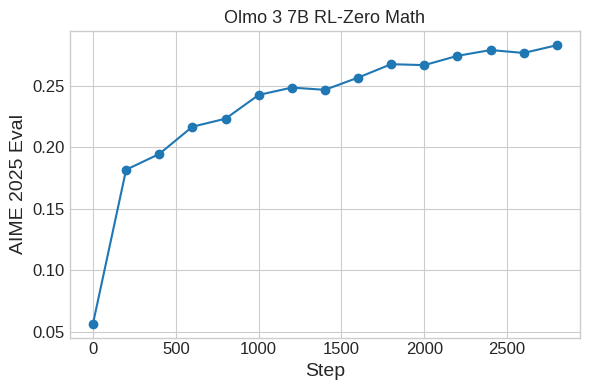

In [6]:
accuracy_summary = merged.groupby("step", as_index=False)["solve_rate"].mean()
initial_accuracy = baseline["initial_pass_at_1"].mean()
accuracy_summary = pd.concat(
    [pd.DataFrame({"step": [0], "solve_rate": [initial_accuracy]}), accuracy_summary],
    ignore_index=True,
).sort_values("step").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(accuracy_summary["step"], accuracy_summary["solve_rate"], marker="o")
ax.set_title("Olmo 3 7B RL-Zero Math", fontsize=13)
ax.set_xlabel("Step", fontsize=14)
ax.set_ylabel("AIME 2025 Eval", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

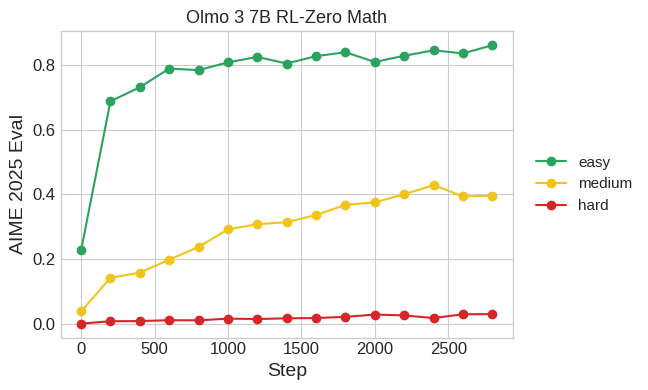

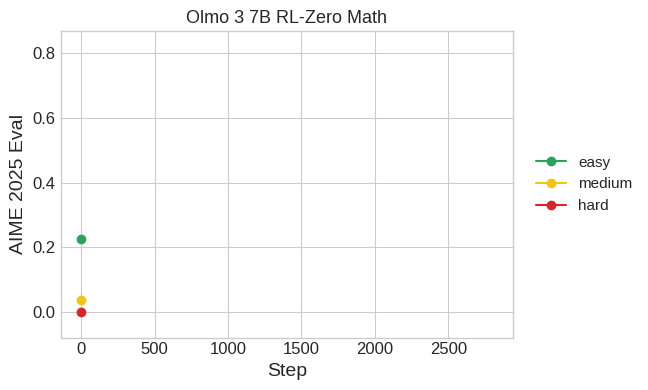

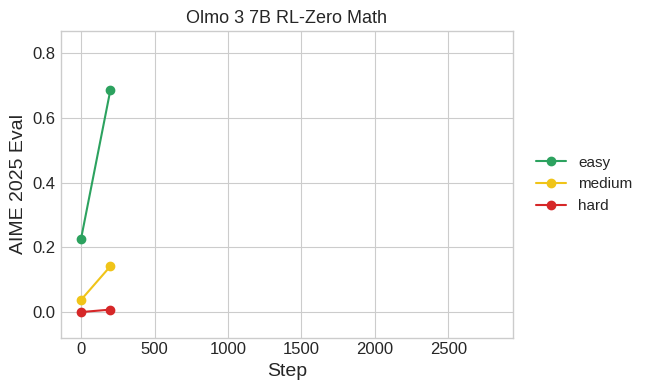

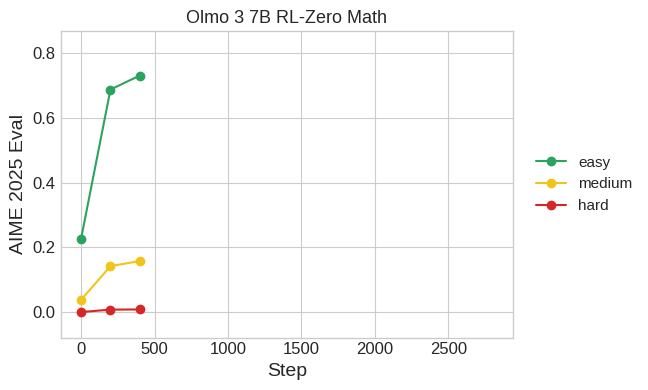

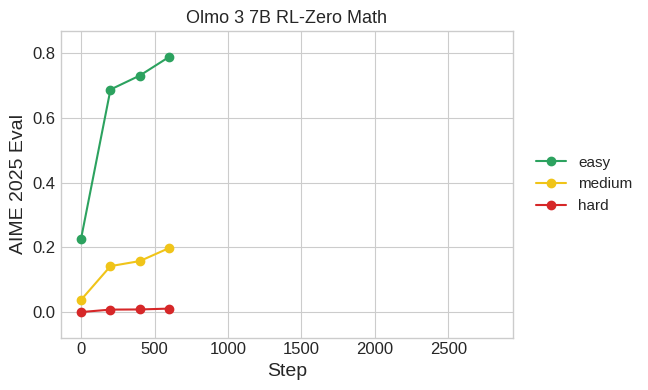

In [7]:
difficulty_accuracy_summary = merged.groupby(["step", "difficulty"], as_index=False)["solve_rate"].mean()
initial_difficulty_accuracy = baseline.groupby("difficulty", as_index=False)["initial_pass_at_1"].mean()
difficulty_accuracy_zero = pd.DataFrame(
    {
        "step": 0,
        "difficulty": initial_difficulty_accuracy["difficulty"],
        "solve_rate": initial_difficulty_accuracy["initial_pass_at_1"],
    }
)
difficulty_accuracy_summary = (
    pd.concat([difficulty_accuracy_zero, difficulty_accuracy_summary], ignore_index=True)
    .sort_values(["difficulty", "step"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(6.6, 4))
for difficulty in DIFFICULTY_ORDER:
    subset = difficulty_accuracy_summary[difficulty_accuracy_summary["difficulty"] == difficulty]
    ax.plot(
        subset["step"],
        subset["solve_rate"],
        marker="o",
        label=difficulty,
        color=DIFFICULTY_COLORS[difficulty],
    )
ax.set_title("Olmo 3 7B RL-Zero Math", fontsize=13)
ax.set_xlabel("Step", fontsize=14)
ax.set_ylabel("AIME 2025 Eval", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

steps_sorted_abs = sorted(difficulty_accuracy_summary["step"].unique())
xmin_abs, xmax_abs = min(steps_sorted_abs), max(steps_sorted_abs)
xmargin_abs = (xmax_abs - xmin_abs) * 0.05
xlim_abs = (xmin_abs - xmargin_abs, xmax_abs + xmargin_abs)

first_four_data_abs = difficulty_accuracy_summary[difficulty_accuracy_summary["step"].isin(steps_sorted_abs[:4])]["solve_rate"]
ymargin_abs = (first_four_data_abs.max() - first_four_data_abs.min()) * 0.1
ylim_abs = (first_four_data_abs.min() - ymargin_abs, first_four_data_abs.max() + ymargin_abs)

for n_points in (1, 2, 3, 4):
    steps_subset_abs = steps_sorted_abs[:n_points]

    fig, ax = plt.subplots(figsize=(6.6, 4))
    for difficulty in DIFFICULTY_ORDER:
        subset = difficulty_accuracy_summary[difficulty_accuracy_summary["difficulty"] == difficulty]
        subset_n = subset[subset["step"].isin(steps_subset_abs)]
        ax.plot(
            subset_n["step"],
            subset_n["solve_rate"],
            marker="o",
            label=difficulty,
            color=DIFFICULTY_COLORS[difficulty],
        )

    ax.set_title("Olmo 3 7B RL-Zero Math", fontsize=13)
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("AIME 2025 Eval", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xlim(xlim_abs)
    ax.set_ylim(ylim_abs)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=11, frameon=False)

    plt.tight_layout()
    plt.show()


## Delta over steps

The first plot shows the mean delta across all dataset indices. The second breaks that mean delta out by quartile.

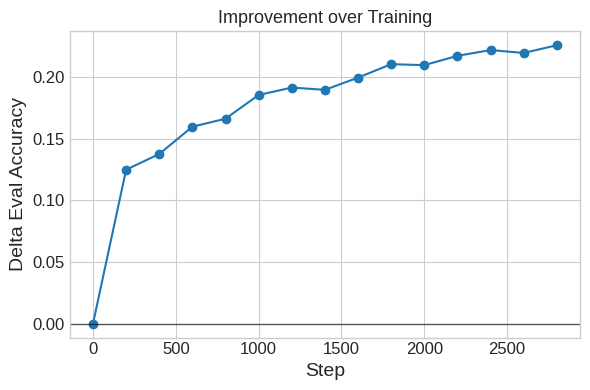

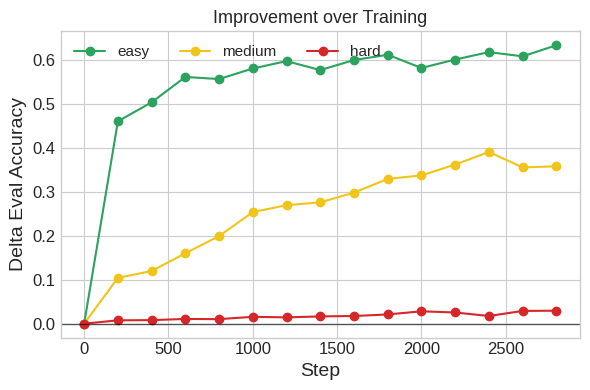

In [8]:
step_summary = merged.groupby("step", as_index=False)["delta_vs_initial_pass_at_1"].mean()
step_summary = pd.concat(
    [pd.DataFrame({"step": [0], "delta_vs_initial_pass_at_1": [0.0]}), step_summary],
    ignore_index=True,
).sort_values("step").reset_index(drop=True)

difficulty_summary = merged.groupby(["step", "difficulty"], as_index=False)["delta_vs_initial_pass_at_1"].mean()
difficulty_zero = pd.DataFrame(
    {
        "step": 0,
        "difficulty": DIFFICULTY_ORDER,
        "delta_vs_initial_pass_at_1": 0.0,
    }
)
difficulty_summary = (
    pd.concat([difficulty_zero, difficulty_summary], ignore_index=True)
    .sort_values(["difficulty", "step"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(step_summary["step"], step_summary["delta_vs_initial_pass_at_1"], marker="o")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Improvement over Training", fontsize=13)
ax.set_xlabel("Step", fontsize=14)
ax.set_ylabel("Delta Eval Accuracy", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for difficulty in DIFFICULTY_ORDER:
    subset = difficulty_summary[difficulty_summary["difficulty"] == difficulty]
    ax.plot(
        subset["step"],
        subset["delta_vs_initial_pass_at_1"],
        marker="o",
        label=difficulty,
        color=DIFFICULTY_COLORS[difficulty],
    )
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Improvement over Training", fontsize=13)
ax.set_xlabel("Step", fontsize=14)
ax.set_ylabel("Delta Eval Accuracy", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(ncol=3, fontsize=11)
plt.tight_layout()
plt.show()


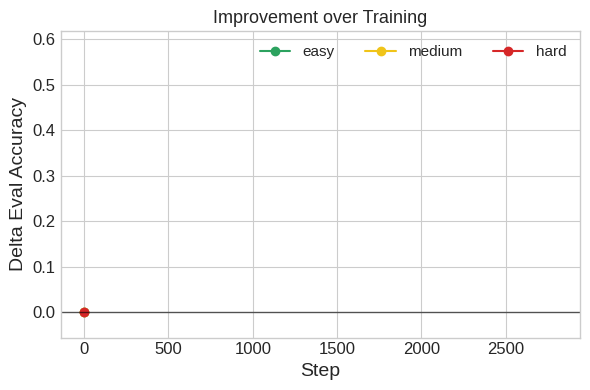

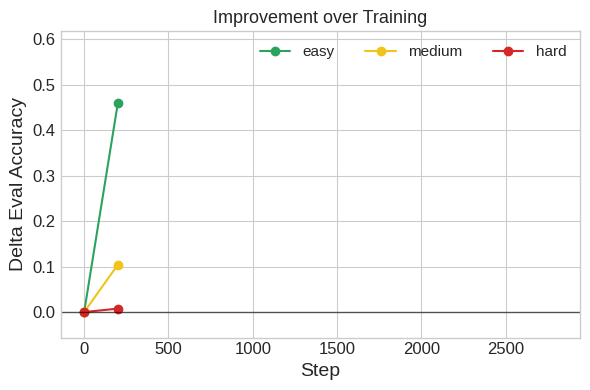

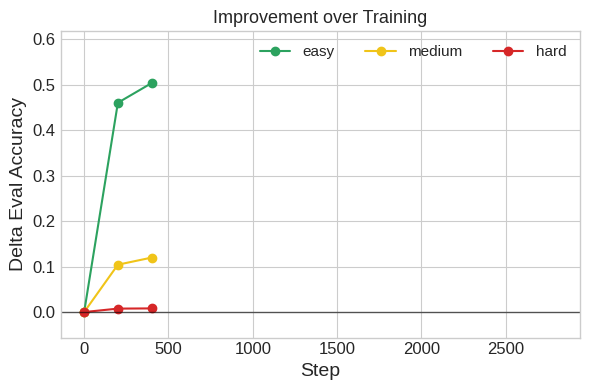

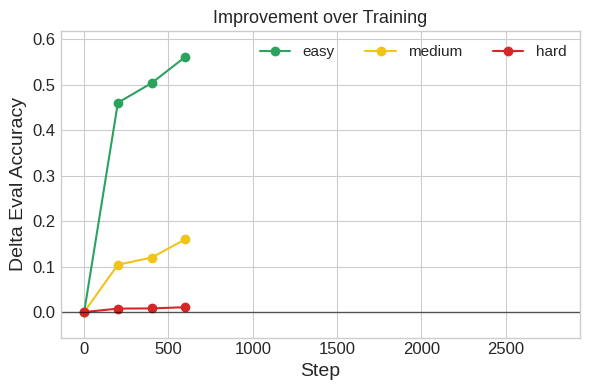

In [9]:
steps_sorted = sorted(difficulty_summary["step"].unique())
xmin, xmax = min(steps_sorted), max(steps_sorted)
xmargin = (xmax - xmin) * 0.05
xlim = (xmin - xmargin, xmax + xmargin)

first_four_data = difficulty_summary[difficulty_summary["step"].isin(steps_sorted[:4])]["delta_vs_initial_pass_at_1"]
ymin = min(0.0, first_four_data.min())
ymax = max(0.0, first_four_data.max())
ymargin = (ymax - ymin) * 0.1
ylim = (ymin - ymargin, ymax + ymargin)

for n_points in (1, 2, 3, 4):
    steps_subset = steps_sorted[:n_points]

    fig, ax = plt.subplots(figsize=(6, 4))
    for difficulty in DIFFICULTY_ORDER:
        subset = difficulty_summary[difficulty_summary["difficulty"] == difficulty]
        subset_n = subset[subset["step"].isin(steps_subset)]
        ax.plot(
            subset_n["step"],
            subset_n["delta_vs_initial_pass_at_1"],
            marker="o",
            label=difficulty,
            color=DIFFICULTY_COLORS[difficulty],
        )

    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_title("Improvement over Training", fontsize=13)
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("Delta Eval Accuracy", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend(ncol=3, fontsize=11)

    plt.tight_layout()
    plt.show()


## Heatmap by dataset index

This is the most direct view of the difference between the initial baseline and each eval checkpoint for every dataset index.

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

DIFFICULTY_CATEGORY = pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
baseline_ordered = baseline.assign(difficulty_order=baseline["difficulty"].astype(DIFFICULTY_CATEGORY)).sort_values(
    ["difficulty_order", "dataset_index"]
)
row_order = baseline_ordered["dataset_index"].tolist()
heatmap = (
    merged.pivot_table(
        index="dataset_index",
        columns="step",
        values="solve_rate",
        aggfunc="mean",
    )
    .reindex(row_order)
)
heatmap.insert(0, 0, baseline.set_index("dataset_index")["initial_pass_at_1"].reindex(heatmap.index))
heatmap = heatmap.sort_index(axis=1)

heatmap_values = heatmap.to_numpy(dtype=float)

solve_rate_cmap = LinearSegmentedColormap.from_list(
    "solve_rate", ["#f1f1ec", "#9ecae1", "#2171b5", "#08306b"]
)

plt.rcParams.update({"font.family": "serif", "font.serif": ["P052", "Palatino", "DejaVu Serif"]})

def plot_heatmap(width, path, **save_kwargs):
    fig, ax = plt.subplots(figsize=(width, 5.0))
    image = ax.imshow(
        heatmap_values,
        aspect="auto",
        origin="lower",
        cmap=solve_rate_cmap,
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xlabel("Step", fontsize=11)
    shown_ticks = np.arange(0, len(heatmap.columns), 3)
    ax.set_xticks(shown_ticks)
    ax.set_xticklabels([heatmap.columns[i] for i in shown_ticks], rotation=45, ha="right")
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=9, length=0)
    ax.grid(False)

    difficulty_sizes = baseline_ordered.groupby("difficulty_order", observed=True).size().tolist()
    boundary = 0
    difficulty_centers = []
    for difficulty, size in zip(DIFFICULTY_ORDER, difficulty_sizes):
        difficulty_centers.append((difficulty, boundary + (size - 1) / 2))
        boundary += size
        if boundary < len(heatmap.index):
            ax.axhline(boundary - 0.5, color="#fffff8", linewidth=2)
    for difficulty, center in difficulty_centers:
        ax.text(-0.75, center, difficulty.title(), rotation=90, ha="center", va="center", fontsize=9, color="#333333")

    colorbar = fig.colorbar(image, ax=ax, shrink=0.8, pad=0.04, ticks=[0.0, 0.5, 1.0])
    colorbar.set_label("Solve Rate", fontsize=11)
    colorbar.ax.tick_params(labelsize=9, length=0)
    colorbar.outline.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    plt.tight_layout(pad=0.25)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, transparent=True, bbox_inches="tight", pad_inches=0.03, **save_kwargs)
    plt.show()


blog_dir = Path("../../mnoukhov.github.io/static/images/ngu")
plot_heatmap(3.5, blog_dir / "aime_per_example_solve_rate.svg", format="svg")
# 2x wider squares for presentations
plot_heatmap(6.5, Path("../notebooks/figures") / "aime_per_example_solve_rate_wide.png", format="png", dpi=300)


## Inspect a single dataset index

Set `DATASET_INDEX_TO_PLOT` to any row index you want to inspect in detail.

,step,dataset_index,dataset,solve_rate,initial_pass_at_1,delta_vs_initial_pass_at_1,name
0,200,0,math_aime_quartile0,0.781250,0.34375,0.437500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
1,400,0,math_aime_quartile0,0.859375,0.34375,0.515625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
2,600,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
3,800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
4,1000,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
5,1200,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
6,1400,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
7,1600,0,math_aime_quartile0,0.984375,0.34375,0.640625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
8,1800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
9,2000,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...


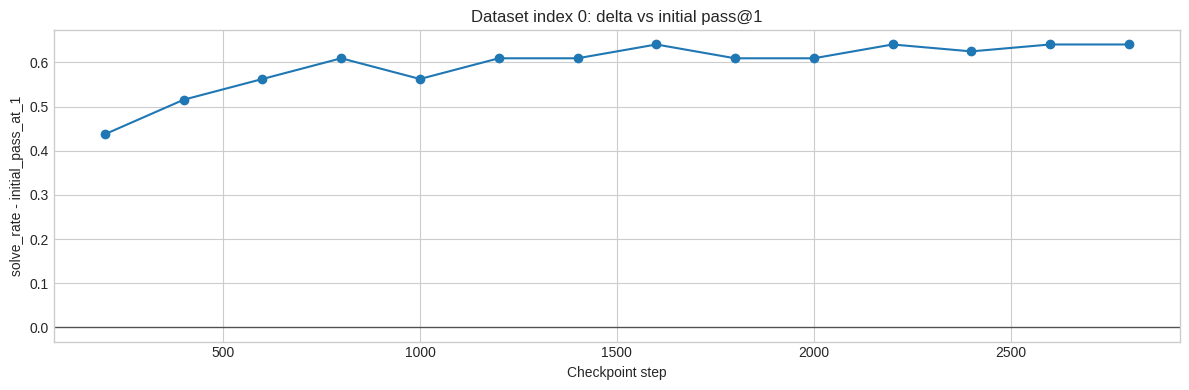

In [11]:
DATASET_INDEX_TO_PLOT = 0

one_index = merged[merged["dataset_index"] == DATASET_INDEX_TO_PLOT].sort_values("step").copy()
display(
    one_index[
        ["step", "dataset_index", "dataset", "solve_rate", "initial_pass_at_1", "delta_vs_initial_pass_at_1", "name"]
    ]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_index["step"], one_index["delta_vs_initial_pass_at_1"], marker="o")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title(f"Dataset index {DATASET_INDEX_TO_PLOT}: delta vs initial pass@1")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("solve_rate - initial_pass_at_1")
plt.tight_layout()
plt.show()


## Quartile pass@1: initial vs final RL checkpoint

For each difficulty quartile, this bar plot shows the initial mean pass@1 in grey and stacks the increase achieved by the final RL checkpoint in green.

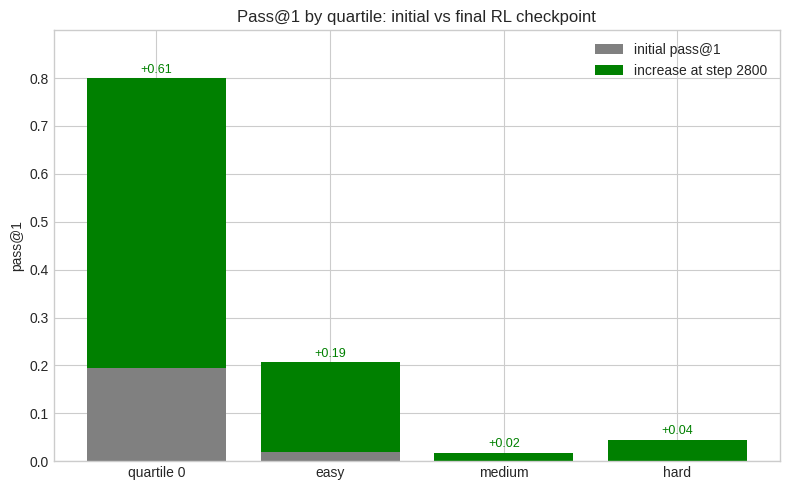

In [12]:
QUARTILE_LABELS = {1: "easy", 2: "medium", 3: "hard", 4: "extra hard"}

final_step = int(merged["step"].max())
final_df = merged[merged["step"] == final_step]

quartile_stats = (
    final_df.groupby("quartile")
    .agg(initial=("initial_pass_at_1", "mean"), final=("solve_rate", "mean"))
    .sort_index()
)
quartile_stats["delta"] = (quartile_stats["final"] - quartile_stats["initial"]).clip(lower=0)

quartiles = quartile_stats.index.astype(int).tolist()
labels = [QUARTILE_LABELS.get(q, f"quartile {q}") for q in quartiles]
initial = quartile_stats["initial"].to_numpy()
delta = quartile_stats["delta"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(quartiles))
ax.bar(x, initial, color="grey", label="initial pass@1")
ax.bar(x, delta, bottom=initial, color="green", label=f"increase at step {final_step}")

for xi, init_val, delta_val in zip(x, initial, delta):
    ax.text(xi, init_val + delta_val + 0.005, f"+{delta_val:.2f}", ha="center", va="bottom", color="green", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("pass@1")
ax.set_title("Pass@1 by quartile: initial vs final RL checkpoint")
ax.set_ylim(0, min(1.0, float((initial + delta).max()) + 0.1))
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
per_example = (
    final_df[["dataset_index", "quartile", "initial_pass_at_1", "solve_rate"]]
    .rename(columns={"solve_rate": "final_pass_at_1"})
    .copy()
)
per_example["difficulty"] = per_example["quartile"].astype(int).map(QUARTILE_LABELS)
per_example["delta"] = per_example["final_pass_at_1"] - per_example["initial_pass_at_1"]
per_example = per_example.sort_values(["quartile", "dataset_index"]).reset_index(drop=True)
per_example = per_example[["dataset_index", "difficulty", "initial_pass_at_1", "final_pass_at_1", "delta"]]

with pd.option_context("display.max_rows", None):
    display(per_example)

,dataset_index,difficulty,initial_pass_at_1,final_pass_at_1,delta
0,0,NaN,0.343750,0.984375,0.640625
1,1,NaN,0.312500,1.000000,0.687500
2,2,NaN,0.250000,0.968750,0.718750
3,3,NaN,0.218750,0.906250,0.687500
4,4,NaN,0.140625,0.484375,0.343750
5,5,NaN,0.109375,0.890625,0.781250
6,6,NaN,0.093750,0.750000,0.656250
7,7,NaN,0.078125,0.640625,0.562500
8,8,NaN,0.421875,0.984375,0.562500
9,9,NaN,0.312500,1.000000,0.687500


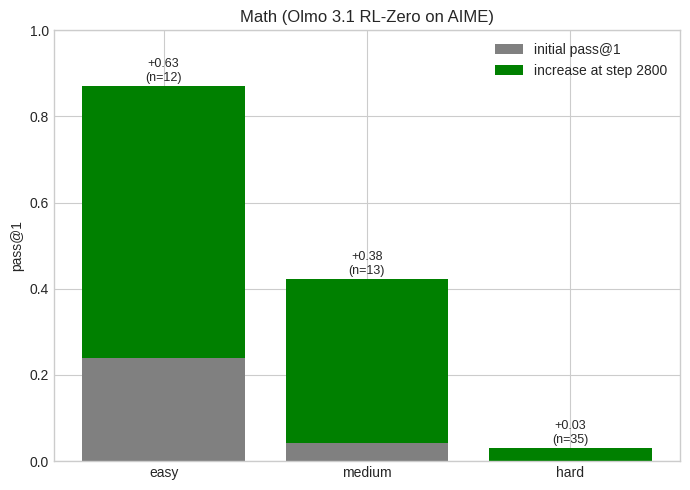

In [14]:
final_with_pc = final_df[["dataset_index", "pass_count", "initial_pass_at_1", "solve_rate"]].copy()

hard_mask = final_with_pc["pass_count"] == 0
hard = final_with_pc[hard_mask]
remainder = final_with_pc[~hard_mask].sort_values("initial_pass_at_1", ascending=False).reset_index(drop=True)

split_point = len(remainder) // 2
easy = remainder.iloc[:split_point]
medium = remainder.iloc[split_point:]

groups = {"easy": easy, "medium": medium, "hard": hard}
labels = list(groups.keys())
initial_means = np.array([g["initial_pass_at_1"].mean() if len(g) else 0.0 for g in groups.values()])
final_means = np.array([g["solve_rate"].mean() if len(g) else 0.0 for g in groups.values()])
deltas = np.clip(final_means - initial_means, a_min=0, a_max=None)
counts = [len(g) for g in groups.values()]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(labels))
ax.bar(x, initial_means, color="grey", label="initial pass@1")
ax.bar(x, deltas, bottom=initial_means, color="green", label=f"increase at step {final_step}")

for xi, init_val, delta_val, n in zip(x, initial_means, deltas, counts):
    ax.text(xi, init_val + delta_val + 0.005, f"+{delta_val:.2f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("pass@1")
ax.set_title("Math (Olmo 3.1 RL-Zero on AIME)")
ax.set_ylim(0, min(1.0, float((initial_means + deltas).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
extracted_buckets = [
    {"bucket": "0/8", "group": "extra hard", "n": 99,  "base": 0,   "after_rl": 5,  "delta": 5},
    {"bucket": "1/8", "group": "hard",       "n": 9,   "base": 12,  "after_rl": 18, "delta": 6},
    {"bucket": "2/8", "group": "hard",       "n": 8,   "base": 25,  "after_rl": 48, "delta": 23},
    {"bucket": "3/8", "group": "hard",       "n": 6,   "base": 38,  "after_rl": 44, "delta": 6},
    {"bucket": "4/8", "group": "medium",     "n": 8,   "base": 50,  "after_rl": 67, "delta": 17},
    {"bucket": "5/8", "group": "medium",     "n": 10,  "base": 62,  "after_rl": 89, "delta": 26},
    {"bucket": "6/8", "group": "medium",     "n": 23,  "base": 75,  "after_rl": 92, "delta": 17},
    {"bucket": "7/8", "group": "easy",       "n": 15,  "base": 88,  "after_rl": 92, "delta": 4},
    {"bucket": "8/8", "group": "easy",       "n": 101, "base": 100, "after_rl": 98, "delta": -2},
]

initial_pass_rate_to_increase_after_rl = {
    0: 5,
    12: 6,
    25: 23,
    38: 6,
    50: 17,
    62: 26,
    75: 17,
    88: 4,
    100: -2,
}

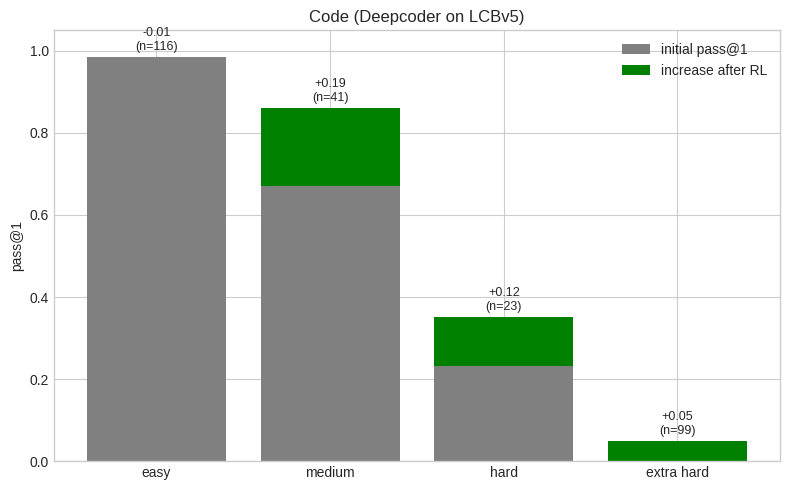

In [16]:
CODE_GROUPS = {
    "easy": {"7/8", "8/8"},
    "medium": {"4/8", "5/8", "6/8"},
    "hard": {"1/8", "2/8", "3/8"},
    "extra hard": {"0/8"},
}

buckets_df = pd.DataFrame(extracted_buckets)

group_labels = ["easy", "medium", "hard", "extra hard"]
initial_means = []
delta_means = []
counts = []
for label in group_labels:
    sub = buckets_df[buckets_df["bucket"].isin(CODE_GROUPS[label])]
    n = sub["n"].sum()
    counts.append(int(n))
    if n > 0:
        initial_means.append((sub["base"] * sub["n"]).sum() / n / 100.0)
        delta_means.append((sub["delta"] * sub["n"]).sum() / n / 100.0)
    else:
        initial_means.append(0.0)
        delta_means.append(0.0)

initial_means = np.array(initial_means)
delta_means = np.array(delta_means)
positive_delta = np.clip(delta_means, a_min=0, a_max=None)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(group_labels))
ax.bar(x, initial_means, color="grey", label="initial pass@1")
ax.bar(x, positive_delta, bottom=initial_means, color="green", label="increase after RL")

for xi, init_val, delta_val, n in zip(x, initial_means, delta_means, counts):
    top = init_val + max(delta_val, 0)
    sign = "+" if delta_val >= 0 else ""
    ax.text(xi, top + 0.01, f"{sign}{delta_val:.2f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(group_labels)
ax.set_ylabel("pass@1")
ax.set_title("Code (Deepcoder on LCBv5)")
ax.set_ylim(0, min(1.05, float((initial_means + positive_delta).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

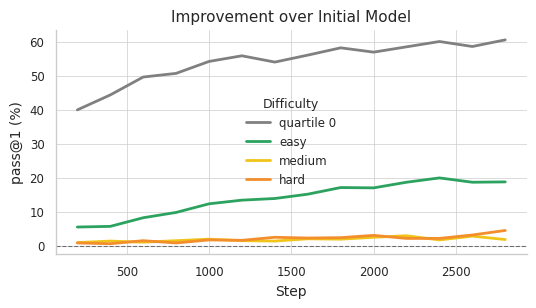

In [17]:
import matplotlib as mpl
import seaborn as sns

QUARTILE_COLORS = {
    1: "#2ca25f",
    2: "#f0c419",
    3: "#f28e2b",
    4: "#d62728",
}
QUARTILE_LABELS = {1: "easy", 2: "medium", 3: "hard", 4: "extra hard"}

OUTPUT_DIR_DAPO = Path("../notebooks/figures") if Path("../notebooks/figures").exists() else Path("notebooks/figures")
OUTPUT_DIR_DAPO.mkdir(parents=True, exist_ok=True)

quartile_summary = (
    merged.groupby(["step", "quartile"], as_index=False)["delta_vs_initial_pass_at_1"]
    .mean()
    .sort_values(["quartile", "step"])
)
quartile_summary["improvement_pct"] = quartile_summary["delta_vs_initial_pass_at_1"] * 100

sns.set_theme(
    context="paper",
    style="whitegrid",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(5.25, 2.97), constrained_layout=True)

for quartile, subset in quartile_summary.groupby("quartile"):
    label = QUARTILE_LABELS.get(int(quartile), f"quartile {int(quartile)}")
    color = QUARTILE_COLORS.get(int(quartile), "grey")
    ax.plot(subset["step"], subset["improvement_pct"], color=color, label=label, linewidth=2.0)

ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Improvement over Initial Model")
ax.set_xlabel("Step")
ax.set_ylabel("pass@1 (%)")
ax.legend(title="Difficulty", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR_DAPO / "dapo_aime_2025_pass_at_1_improvement_by_difficulty.pdf", bbox_inches="tight", pad_inches=0.02)